# Denosing Code Challenge

In [413]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
from matplotlib.pyplot import plot, figure, show
from rich import print

In [414]:
def ejes(plt):
    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.grid(alpha=0.5)
    plt.tight_layout()

# Load the data
data = sio.loadmat('denoising_codeChallenge.mat')
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'cleanedSignal', 'origSignal'])

In [415]:
# show data keys headers
print(data['origSignal'])
print(data['cleanedSignal'])

[[ 0.34069747 -0.29900363 -0.92773336 ...  1.23675819 -0.77687497
  -0.10484616]]

[[-0.45891912 -0.47168064 -0.48151474 ... -0.43723537 -0.44782886
  -0.44533749]]

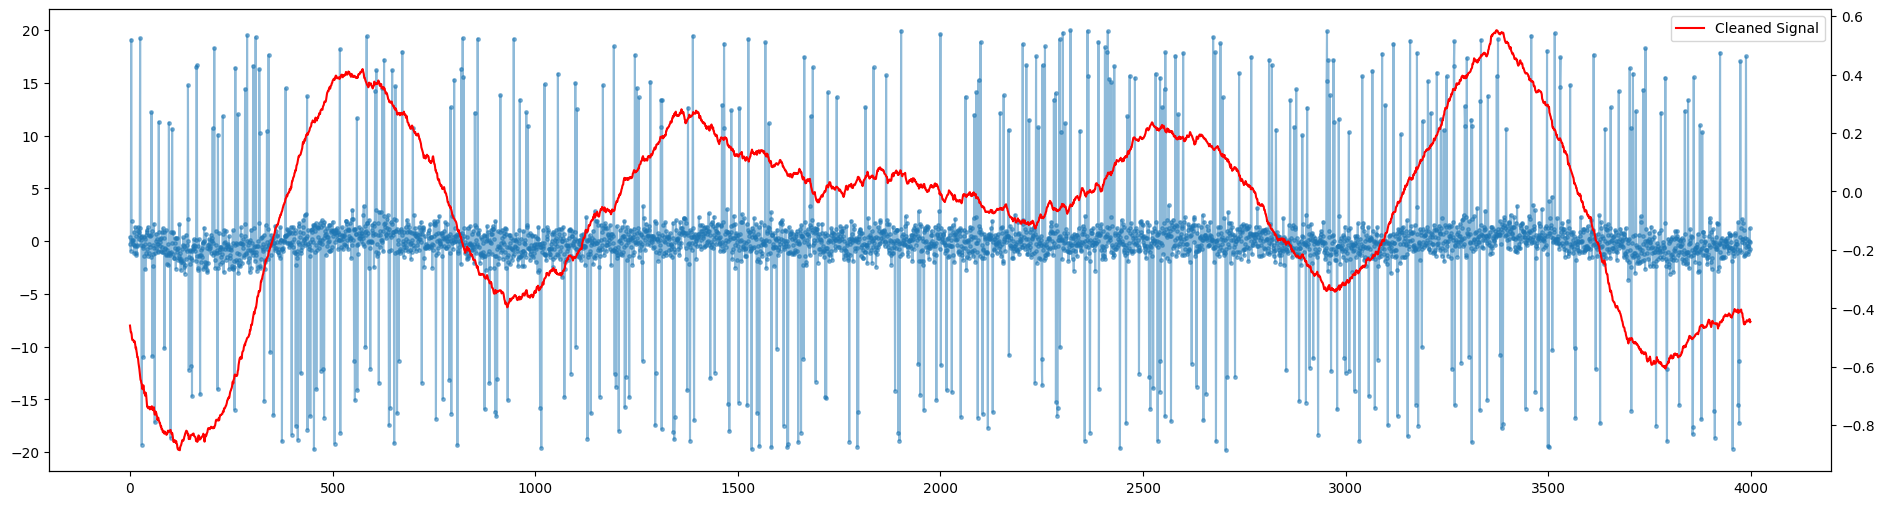

In [416]:
# Extract the data
origSignal = data['origSignal'][0]
cleanedSignal = data['cleanedSignal'][0]

# Plot the data
figure(figsize=(23, 6))
plot(origSignal, '.-', label='Original Signal', alpha=0.5, markersize=5)
# plot cleaned signal in the right axis
ax2 = plt.gca().twinx()
ax2.plot(cleanedSignal, 'r', label='Cleaned Signal')
plt.legend()
show()

### Implement the median filter

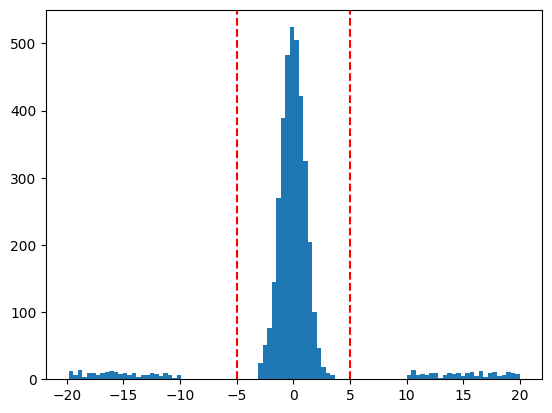

In [ ]:
# use hist to pick threshold
plt.hist(origSignal, 100) # type: ignore
plt.axvline(5, color="r", linestyle="--")
plt.axvline(-5, color="r", linestyle="--")
plt.show()

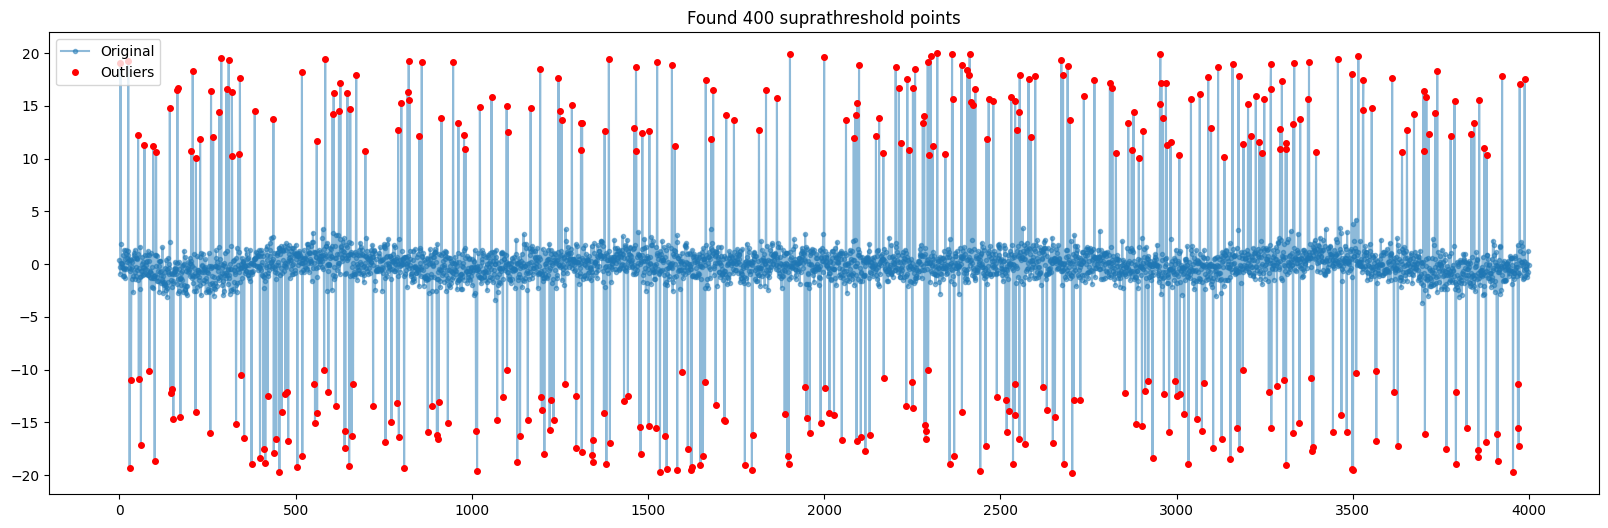

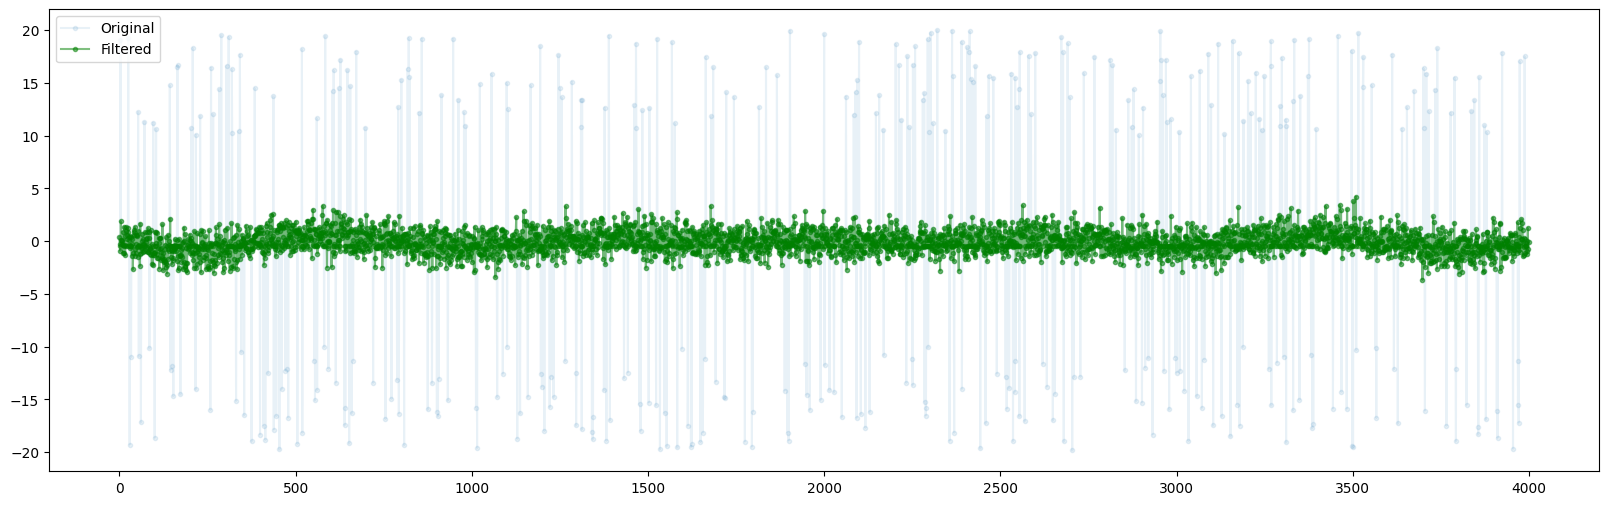

In [418]:
# visual-picked thresholds
import copy

threshold = 5  # positive threshold

# find data values above or below the thresholds
suprathresh = np.where(abs(origSignal) > threshold)[0]
n = len(origSignal)

# initialize filtered origSignal
filtsig = copy.deepcopy(origSignal)

plt.figure(figsize=(20, 6))
plt.plot(range(0, n), origSignal, '.-', alpha=0.5, label='Original')
plt.plot(suprathresh, origSignal[suprathresh], 'r.', label='Outliers', markersize=8)
plt.title(f'Found {len(suprathresh)} suprathreshold points')
plt.legend()
plt.show()

# loop through suprathreshold points and set to median of k
k = 5  # actual window is k*2+1
for ti in range(len(suprathresh)):
    # lower and upper bounds
    lowbnd = np.max((0, suprathresh[ti] - k))
    uppbnd = np.min((suprathresh[ti] + k + 1, n))

    # compute median of surrounding points
    filtsig[suprathresh] = np.median(origSignal[lowbnd:uppbnd])

# plot
plt.figure(figsize=(20, 6))
plt.plot(range(0, n), origSignal, '.-', alpha=0.1, label='Original')
plt.plot(range(0, n), filtsig, 'g.-', alpha=0.5, label='Filtered')
plt.legend()
plt.show()

### Use a scipy function to implement a gaussian filter

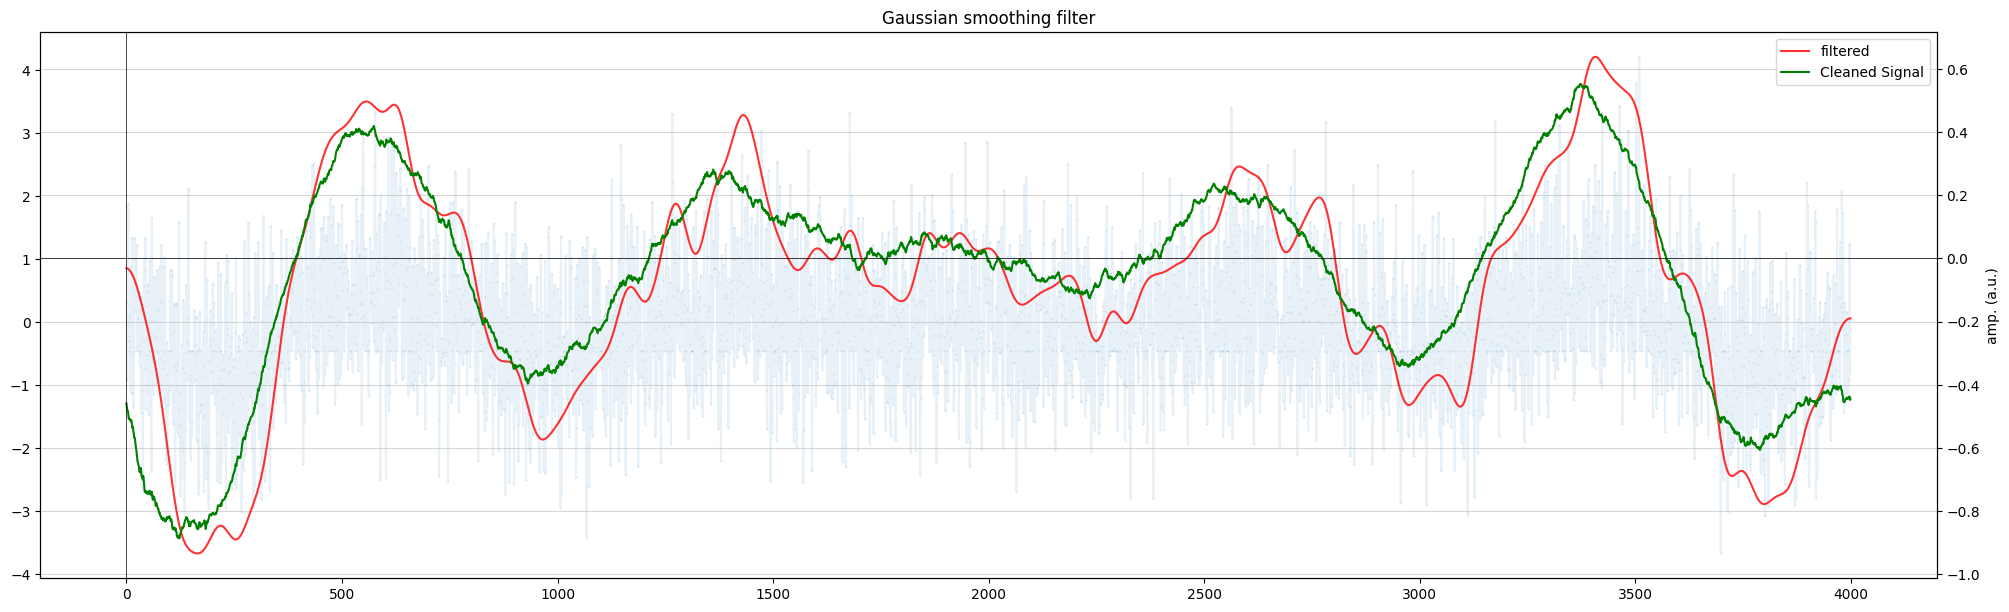

In [422]:
# Use a scipy function to implement a gaussian filter
import time
from scipy.ndimage import gaussian_filter1d

filtsig2 = gaussian_filter1d(filtsig, sigma=25)
time = np.arange(0, len(filtsig))  # in seconds
# plot
plt.figure(figsize=(20, 6))
plt.plot(time, filtsig, '.-', label="orig", markersize=1, alpha=0.1)
ax2 = plt.gca().twinx()
ax2.plot(time, filtsig2, 'r-', label="filtered", alpha=0.8)
ax2.plot(cleanedSignal, 'g', label='Cleaned Signal')
ejes(plt)

plt.xlabel("Time (s)")
plt.ylabel("amp. (a.u.)")
plt.legend()
plt.title("Gaussian smoothing filter")
plt.show()


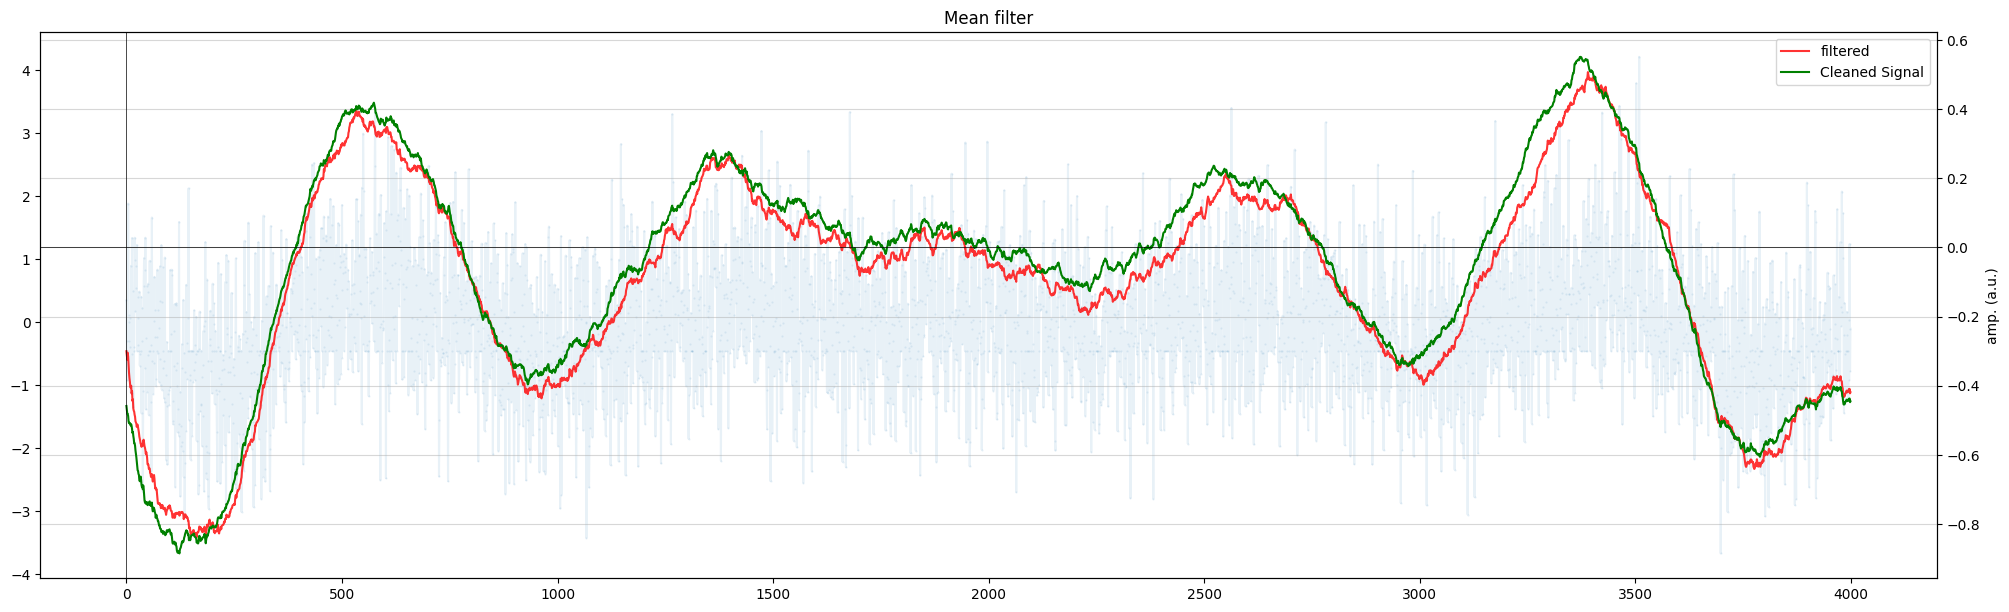

In [ ]:
# now compare using a media moving filter
k_mean = 120

filt_sig = copy.deepcopy(filtsig)
n = len(filt_sig)
for i in range(n):
    lower_bound = max(0, i-k_mean)
    upper_bound = min(n, i+k_mean)
    filt_sig[i] = np.mean(filt_sig[lower_bound:upper_bound])    

# plot
plt.figure(figsize=(20, 6))
plt.plot(time, filtsig, '.-', label="orig", markersize=1, alpha=0.1) # type: ignore
ax2 = plt.gca().twinx()
ax2.plot(time, filt_sig, 'r-', label="filtered", alpha=0.8) # type: ignore
ax2.plot(cleanedSignal, 'g', label='Cleaned Signal')
ejes(plt)

plt.xlabel("Time (s)")
plt.ylabel("amp. (a.u.)")
plt.legend()
plt.title("Mean filter")
plt.show()
